# Pipeline In Silico — Piper tuberculatum vs HCT-116
**T**

Pipeline: GC-MS → identidad química → bioactividad (ChEMBL) →
predicción de dianas (SwissTP) → relevancia CRC (OpenTargets) →
pathway enrichment → PPI → integración → priorización


In [1]:
!pip install pubchempy gseapy mygene python-louvain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 4.2 MB/s eta 0:00:00


In [37]:
# CELDA 1: Imports y configuración
# ============================================================

import os
import sys
import pandas as pd

# Si pipeline_lib.py está en el mismo directorio:
from pipeline_lib import (
    PipelineConfig,
    resolve_compounds,
    query_chembl_bioactivity,
    get_chembl_activity_details,
    load_swisstarget_predictions,
    filter_predictions,
    standardize_gene_symbols,
    query_crc_relevance,
    run_pathway_enrichment,
    build_ppi_network,
    get_ppi_metrics,
    build_integration_table,
    calculate_priority_score,
    create_phenotype_bridge,
    plot_enrichment_barplot,
    plot_ppi_network,
    plot_compound_target_heatmap,
)

# ---- Configuración central ----
cfg = PipelineConfig()

# SwissTP: retener solo predicciones con probabilidad ≥ 0.10
# Justificación: con 0.03 retienes 349/400 (87%), demasiado ruido.
# Con 0.10 retienes ~113 (las que ya marcaste como HIGH confidence).
# Esto reduce genes de ~223 a ~80-100, limpiando enrichment y PPI.
cfg.swisstarget_prob_low = 0.10

# Marca de alta confianza dentro de las retenidas
# (las de P ≥ 0.20 son las más robustas)
cfg.swisstarget_prob_high = 0.20

# FDR para enrichment: 0.05 es estándar, no lo cambies
cfg.enrichment_fdr_threshold = 0.05

# STRING: score ≥ 700 es un umbral alto (high confidence).
# Está bien — mejor pocos edges reales que muchos falsos.
cfg.string_score_threshold = 700

os.makedirs(cfg.output_dir, exist_ok=True)

print("Pipeline configurado.")
print(f"  Compuestos: {len(cfg.compounds)}")
print(f"  SwissTP threshold: ≥{cfg.swisstarget_prob_low} "
      f"(alta confianza: ≥{cfg.swisstarget_prob_high})")
print(f"  Enrichment FDR: <{cfg.enrichment_fdr_threshold}")
print(f"  STRING score: ≥{cfg.string_score_threshold}")



Pipeline configurado.
  Compuestos: 4
  SwissTP threshold: ≥0.1 (alta confianza: ≥0.2)
  Enrichment FDR: <0.05
  STRING score: ≥700


In [39]:
# CELDA 2: PASO 1 — Identidad química (PubChem)
# ============================================================
# Pregunta: ¿Cuáles son exactamente los compuestos mayoritarios
# del aceite esencial y cuál es su estructura?

print("\n" + "="*60)
print("PASO 1: Resolución de identidad química (PubChem)")
print("="*60)

df_identity = resolve_compounds(cfg.compounds, delay=cfg.api_delay)

print("\n--- Tabla de identidad ---")
print(df_identity[["query_name", "gcms_percent", "status", "cid",
                    "molecular_formula"]].to_string(index=False))

# NOTA para beta-cis-Ocimene:
ocimene = df_identity[df_identity["query_name"] == "beta-cis-Ocimene"]
if not ocimene.empty:
    print(f"\n⚠ VERIFICACIÓN REQUERIDA para beta-cis-Ocimene:")
    print(f"  CID usado: {ocimene.iloc[0]['cid']}")
    print(f"  SMILES: {ocimene.iloc[0]['smiles']}")
    print(f"  Nota: {ocimene.iloc[0]['note']}")
    print("  → Confirmar que este CID corresponde al isómero de tu GC-MS")
    print("    comparando con el índice de retención reportado.")

df_identity.to_csv(os.path.join(cfg.output_dir, "01_identity.csv"),
                    index=False)




PASO 1: Resolución de identidad química (PubChem)


/content/pipeline_lib.py:182: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  smiles=c.isomeric_smiles,



--- Tabla de identidad ---
                              query_name  gcms_percent                        status      cid molecular_formula
                        beta-cis-Ocimene         28.22 FOUND (CID verificado manual)  5281553            C10H16
Germacra-4(15),5,10(14)-trien-1-alpha-ol         15.60 FOUND (CID verificado manual) 13304977           C15H24O
                               Croweacin         15.64                         FOUND  5316141          C11H12O3
                     Caryophyllene oxide         10.50                         FOUND  1742210           C15H24O

⚠ VERIFICACIÓN REQUERIDA para beta-cis-Ocimene:
  CID usado: 5281553
  SMILES: CC(=CC/C=C(\C)/C=C)C
  Nota: CID 5281553 = (Z)-beta-ocimene (C10H16, acíclico). ALERTA: la Fig.9 del paper fuente muestra una estructura con O que NO coincide con ocimene. Verificar identidad con autores/tutor. IR exp=1166, IR ref=1173.
  → Confirmar que este CID corresponde al isómero de tu GC-MS
    comparando con el índice de r

In [40]:
# CELDA 3: PASO 2 — Bioactividad experimental (ChEMBL)
# ============================================================
# Pregunta: ¿Alguno de estos compuestos tiene actividad biológica
# reportada experimentalmente contra dianas humanas?

print("\n" + "="*60)
print("PASO 2: Bioactividad experimental (ChEMBL)")
print("="*60)

# ChEMBL usa la API REST del EBI que puede estar temporalmente caída.
# Si falla, el pipeline continúa — ChEMBL aporta evidencia adicional
# pero no es bloqueante para el análisis de dianas.
_chembl_ok = True
try:
    df_chembl = query_chembl_bioactivity(df_identity,
                                         organism=cfg.chembl_organism,
                                         delay=cfg.api_delay)

    print("\n--- Resumen ChEMBL ---")
    print(df_chembl.to_string(index=False))

    # Tabla maestra: identidad + ChEMBL
    df_master = df_identity.merge(
        df_chembl, left_on="query_name", right_on="compound", how="left"
    )
    df_master = df_master.drop(columns=["compound"], errors="ignore")

    df_master.to_csv(os.path.join(cfg.output_dir, "02_master_identity.csv"),
                      index=False)
    print(f"\nTabla maestra guardada ({len(df_master)} compuestos).")

except Exception as e:
    _chembl_ok = False
    print(f"\n  ⚠ ChEMBL API no disponible: {type(e).__name__}: {e}")
    print("  Esto es un error del servidor de EBI, no de tu código.")
    print("  El pipeline continúa sin datos de ChEMBL.")
    print("  Reintenta más tarde o continúa — este paso es complementario.")
    df_chembl = pd.DataFrame(columns=["compound", "chembl_id",
                                       "chembl_status", "n_activities"])
    df_master = df_identity.copy()
    df_master.to_csv(os.path.join(cfg.output_dir, "02_master_identity.csv"),
                      index=False)




PASO 2: Bioactividad experimental (ChEMBL)
  Buscando beta-cis-Ocimene en ChEMBL...
    → CHEMBL2228374: 0 actividades
  Buscando Germacra-4(15),5,10(14)-trien-1-alpha-ol en ChEMBL...
    → CHEMBL3262201: 0 actividades
  Buscando Croweacin en ChEMBL...
  Buscando Caryophyllene oxide en ChEMBL...
    → CHEMBL399036: 10 actividades

--- Resumen ChEMBL ---
                                compound     chembl_id           chembl_status  n_activities
                        beta-cis-Ocimene CHEMBL2228374 SIN ACTIVIDAD EN HUMANO             0
Germacra-4(15),5,10(14)-trien-1-alpha-ol CHEMBL3262201 SIN ACTIVIDAD EN HUMANO             0
                               Croweacin          None           NO ENCONTRADO             0
                     Caryophyllene oxide  CHEMBL399036           CON ACTIVIDAD            10

Tabla maestra guardada (4 compuestos).


In [41]:
# CELDA 4: PASO 2b — Detalle de actividades ChEMBL (por compuesto)
# ============================================================
# Pregunta: Para compuestos con actividad reportada,
# ¿contra qué dianas específicas actúan?

print("\n" + "="*60)
print("PASO 2b: Detalle de actividades por compuesto")
print("="*60)

chembl_details_all = []
df_chembl_detail = pd.DataFrame()

if _chembl_ok and not df_chembl.empty:
    for _, row in df_chembl.iterrows():
        if row.get("chembl_id") and row.get("n_activities", 0) > 0:
            print(f"\n  {row['compound']} ({row['chembl_id']}): "
                  f"{row['n_activities']} actividades")
            try:
                df_detail = get_chembl_activity_details(
                    row["chembl_id"], organism=cfg.chembl_organism)
                if not df_detail.empty:
                    df_detail["compound"] = row["compound"]
                    chembl_details_all.append(df_detail)

                    single = df_detail[df_detail["target_type"] == "SINGLE PROTEIN"]
                    if not single.empty:
                        print(f"    Proteínas individuales: {len(single)}")
                        print(single[["target_name", "standard_type",
                                      "standard_value", "standard_units"]]
                              .head(10).to_string(index=False))
            except Exception as e:
                print(f"    [ERROR detalle] {e}")

    if chembl_details_all:
        df_chembl_detail = pd.concat(chembl_details_all, ignore_index=True)
        df_chembl_detail.to_csv(
            os.path.join(cfg.output_dir, "02b_chembl_details.csv"), index=False)
        print(f"\nDetalle ChEMBL guardado ({len(df_chembl_detail)} registros).")
    else:
        print("\nSin actividades detalladas disponibles.")
else:
    print("  Omitido: ChEMBL no disponible o sin resultados.")




PASO 2b: Detalle de actividades por compuesto

  Caryophyllene oxide (CHEMBL399036): 10 actividades

Detalle ChEMBL guardado (10 registros).


In [42]:
# CELDA 5: PASO 3 — Predicción de dianas (SwissTargetPrediction)
# ============================================================
# Pregunta: ¿Qué dianas moleculares podrían ser afectadas
# por estos compuestos según similaridad estructural?
#
# NOTA: SwissTP no tiene API pública.  Los CSVs se descargan
# manualmente de http://www.swisstargetprediction.ch/
# ingresando el SMILES de cada compuesto.

print("\n" + "="*60)
print("PASO 3: Predicción de dianas (SwissTargetPrediction)")
print("="*60)

try:
    df_swisstp_raw = load_swisstarget_predictions(cfg.swisstarget_files)
    print(f"  Predicciones cargadas: {len(df_swisstp_raw)}")
    print(f"  Compuestos: {df_swisstp_raw['compound'].nunique()}")

    df_targets = filter_predictions(
        df_swisstp_raw,
        prob_threshold=cfg.swisstarget_prob_low,
        prob_high=cfg.swisstarget_prob_high,
        min_known_actives=cfg.min_known_actives,
    )

    print(f"\n  Predicciones retenidas (P ≥ {cfg.swisstarget_prob_low}): "
          f"{len(df_targets)}")
    print(f"  De alta confianza (P ≥ {cfg.swisstarget_prob_high}): "
          f"{(df_targets['confidence'] == 'HIGH').sum()}")
    print(f"  De baja referencia: "
          f"{(df_targets['confidence'] == 'LOW_REFERENCE').sum()}")

    print("\n  Por compuesto:")
    print(df_targets.groupby("compound").size().to_string())

    df_targets.to_csv(
        os.path.join(cfg.output_dir, "03_swisstarget_filtered.csv"),
        index=False)

except FileNotFoundError as e:
    print(f"  [ERROR] {e}")
    print("  Asegúrate de que los CSVs de SwissTP estén en el directorio.")
    print("  Archivos esperados:")
    for f in cfg.swisstarget_files:
        print(f"    {f}")
    df_targets = pd.DataFrame()




PASO 3: Predicción de dianas (SwissTargetPrediction)
  Predicciones cargadas: 400
  Compuestos: 4

  Predicciones retenidas (P ≥ 0.1): 124
  De alta confianza (P ≥ 0.2): 42
  De baja referencia: 11

  Por compuesto:
compound
Caryophyllene oxide                         30
Croweacin                                   74
Germacra-4(15),5,10(14)-trien-1-alpha-ol     9
beta-cis-Ocimene                            11


In [43]:
# CELDA 6: PASO 4 — Estandarización de símbolos génicos
# ============================================================
# Pregunta: ¿Los identificadores de genes son correctos y
# corresponden a símbolos oficiales HGNC?

print("\n" + "="*60)
print("PASO 4: Estandarización de símbolos génicos")
print("="*60)

if not df_targets.empty:
    df_targets_std = standardize_gene_symbols(df_targets,
                                              delay=cfg.api_delay)

    # Análisis de convergencia
    convergence = (df_targets_std.groupby("gene_symbol")["compound"]
                   .nunique().reset_index()
                   .rename(columns={"compound": "n_compounds"})
                   .sort_values("n_compounds", ascending=False))

    multi = convergence[convergence["n_compounds"] > 1]
    print(f"\n  Total genes únicos: {len(convergence)}")
    print(f"  Genes en ≥2 compuestos: {len(multi)}")
    if not multi.empty:
        print("\n  Genes convergentes:")
        print(multi.to_string(index=False))

    df_targets_std.to_csv(
        os.path.join(cfg.output_dir, "04_targets_standardized.csv"),
        index=False)
    convergence.to_csv(
        os.path.join(cfg.output_dir, "04_gene_convergence.csv"),
        index=False)
else:
    df_targets_std = pd.DataFrame()
    convergence = pd.DataFrame()
    print("  Omitido: sin predicciones de targets.")



INFO:biothings.client:querying 1-97 ...



PASO 4: Estandarización de símbolos génicos
  Eliminadas 7 filas sin gene_symbol resuelto.


INFO:biothings.client:Finished.



  Total genes únicos: 97
  Genes en ≥2 compuestos: 18

  Genes convergentes:
gene_symbol  n_compounds
       ACHE            3
    CYP19A1            3
       CNR2            2
         AR            2
      ALOX5            2
     CYP1B1            2
     SLC6A4            2
      PTGS2            2
      PTGS1            2
      PPARA            2
       SHBG            2
        LSS            2
      NR1H3            2
      NR1H4            2
       MAOB            2
      NR1H2            2
      HMGCR            2
     SLC6A2            2


In [44]:
# CELDA 7: PASO 5 — Relevancia en cáncer colorrectal (OpenTargets)
# ============================================================
# Pregunta: ¿Cuáles de las dianas predichas tienen evidencia
# de asociación con cáncer colorrectal en la literatura?

print("\n" + "="*60)
print("PASO 5: Relevancia CRC (OpenTargets)")
print("="*60)

if not df_targets_std.empty:
    gene_list = df_targets_std["gene_symbol"].unique().tolist()

    # Si existe un cache previo con errores, borrarlo para re-consultar
    cache_file = os.path.join(cfg.output_dir, "05_crc_relevance_cache.csv")
    if os.path.isfile(cache_file):
        try:
            _cache_check = pd.read_csv(cache_file)
            _n_errors = (_cache_check.get("crc_relevance", pd.Series()) == "ERROR").sum()
            if _n_errors > len(_cache_check) * 0.5:
                print(f"  Cache anterior tiene {_n_errors}/{len(_cache_check)} errores. "
                      "Borrando para re-consultar...")
                os.remove(cache_file)
        except Exception:
            pass

    df_crc = query_crc_relevance(
        gene_list,
        disease_ids=cfg.crc_disease_ids,
        delay=cfg.api_delay,
        cache_path=cache_file
    )

    print(f"\n  Distribución de relevancia CRC:")
    print(df_crc["crc_relevance"].value_counts().to_string())

    df_crc.to_csv(os.path.join(cfg.output_dir, "05_crc_relevance.csv"),
                   index=False)
else:
    df_crc = pd.DataFrame()
    print("  Omitido: sin genes para consultar.")




PASO 5: Relevancia CRC (OpenTargets)
  Consultando OpenTargets para 97 genes...
    ... 10/97 (encontrados: 9, con CRC: 7)
    ... 20/97 (encontrados: 19, con CRC: 16)
    ... 30/97 (encontrados: 29, con CRC: 22)
    ... 40/97 (encontrados: 39, con CRC: 32)
    ... 50/97 (encontrados: 49, con CRC: 41)
    ... 60/97 (encontrados: 59, con CRC: 50)
    ... 70/97 (encontrados: 69, con CRC: 56)
    ... 80/97 (encontrados: 79, con CRC: 65)
    ... 90/97 (encontrados: 89, con CRC: 74)
  Cache guardada: outputs/05_crc_relevance_cache.csv

  Distribución de relevancia CRC:
crc_relevance
WEAK        61
MODERATE    18
NONE        17
STRONG       1


In [45]:
# CELDA 8: PASO 6 — Enriquecimiento de vías
# ============================================================
# Pregunta: ¿Las dianas predichas convergen en vías biológicas
# relevantes para cáncer (apoptosis, ciclo celular, PI3K-AKT,
# Wnt, ROS, MAPK)?

print("\n" + "="*60)
print("PASO 6: Enriquecimiento de vías (ORA)")
print("="*60)

if not df_targets_std.empty:
    gene_list_enr = df_targets_std["gene_symbol"].unique().tolist()
    print(f"  Genes en input: {len(gene_list_enr)}")

    df_enrichment = run_pathway_enrichment(
        gene_list_enr,
        gene_sets=cfg.enrichment_gene_sets,
        fdr_threshold=cfg.enrichment_fdr_threshold,
        output_dir=cfg.output_dir,
    )

    if not df_enrichment.empty:
        print(f"\n  Total términos significativos: {len(df_enrichment)}")
        print(f"\n  Top 15 por combined score:")
        top = df_enrichment.nlargest(15, "combined_score")
        print(top[["gene_set_library", "term", "fdr",
                    "combined_score"]].to_string(index=False))

        # Buscar vías de interés para la tesis
        keywords_of_interest = [
            "apoptosis", "cell cycle", "pi3k", "akt", "wnt",
            "beta-catenin", "oxidative", "reactive oxygen", "ros",
            "mapk", "cancer", "colorectal", "proliferat",
            "death", "survival", "nf-kb", "p53", "tnf",
        ]
        mask = df_enrichment["term"].str.lower().apply(
            lambda t: any(k in t for k in keywords_of_interest))
        cancer_related = df_enrichment[mask]

        if not cancer_related.empty:
            print(f"\n  Vías potencialmente relevantes para cáncer/ROS "
                  f"({len(cancer_related)}):")
            print(cancer_related[["gene_set_library", "term", "fdr"]]
                  .to_string(index=False))
        else:
            print("\n  Ninguna vía directamente nombrada con keywords "
                  "de cáncer/ROS. Esto NO significa ausencia de "
                  "relevancia — revisar términos manualmente.")
else:
    df_enrichment = pd.DataFrame()
    print("  Omitido: sin genes para enrichment.")




PASO 6: Enriquecimiento de vías (ORA)
  Genes en input: 97
  Enrichment: KEGG_2021_Human ...
    204 términos significativos (FDR < 0.05)
  Enrichment: Reactome_2022 ...
    557 términos significativos (FDR < 0.05)
  Enrichment: GO_Biological_Process_2023 ...
    1483 términos significativos (FDR < 0.05)
  Guardado: outputs/pathway_enrichment.csv

  Total términos significativos: 2244

  Top 15 por combined score:
          gene_set_library                                                                              term          fdr  combined_score
             Reactome_2022                                           Neurotransmitter Clearance R-HSA-112311 3.321907e-08     4593.431600
GO_Biological_Process_2023                           Negative Regulation Of Cholesterol Storage (GO:0010887) 4.832987e-06     3668.257168
             Reactome_2022                              SUMOylation Of Intracellular Receptors R-HSA-4090294 1.306469e-12     3284.080514
             Reactome_2022   

In [46]:
# CELDA 9: PASO 7 — Red PPI (STRING)
# ============================================================
# Pregunta: ¿Las dianas predichas forman módulos funcionales
# interconectados o son hits dispersos sin relación?

print("\n" + "="*60)
print("PASO 7: Red PPI (STRING)")
print("="*60)

if not df_targets_std.empty:
    gene_list_ppi = df_targets_std["gene_symbol"].unique().tolist()

    G_ppi, df_ppi = build_ppi_network(
        gene_list_ppi,
        species=cfg.string_species,
        score_threshold=cfg.string_score_threshold,
        output_dir=cfg.output_dir,
    )

    df_ppi_metrics = get_ppi_metrics(G_ppi)

    if not df_ppi_metrics.empty:
        print(f"\n  Top 10 hubs (por degree):")
        print(df_ppi_metrics.head(10)[
            ["gene_symbol", "ppi_degree", "ppi_betweenness", "ppi_cluster"]
        ].to_string(index=False))

        n_clusters = df_ppi_metrics["ppi_cluster"].nunique()
        print(f"\n  Clusters detectados: {n_clusters}")

        df_ppi_metrics.to_csv(
            os.path.join(cfg.output_dir, "07_ppi_metrics.csv"), index=False)
else:
    G_ppi = None
    df_ppi_metrics = pd.DataFrame()
    print("  Omitido: sin genes para PPI.")




PASO 7: Red PPI (STRING)
  Consultando STRING (97 genes, score ≥ 700)...
  Nodos: 97 (15 aislados)
  Interacciones: 199

  Top 10 hubs (por degree):
gene_symbol  ppi_degree  ppi_betweenness  ppi_cluster
   HSP90AA1          15         0.114039            6
     SREBF1          15         0.065969            3
      PPARA          13         0.145251            3
      EP300          13         0.119658            6
     SREBF2          12         0.037814            3
      PPARG          12         0.084160            3
      HIF1A          12         0.068836            6
       ESR1          11         0.044921            6
      PTGS2          10         0.079751            0
       MAOA           9         0.039729            2

  Clusters detectados: 21


In [47]:
# CELDA 10: PASO 8 — Integración y priorización
# ============================================================
# Pregunta: ¿Qué dianas candidatas acumulan mayor evidencia
# desde múltiples perspectivas?

print("\n" + "="*60)
print("PASO 8: Integración y priorización")
print("="*60)

if not df_targets_std.empty:
    df_integrated = build_integration_table(
        df_targets_std, df_crc, df_enrichment, df_ppi_metrics)

    df_prioritized = calculate_priority_score(df_integrated)

    print(f"\n  Total genes candidatos: {len(df_prioritized)}")
    print(f"\n  Top 20 por priority score:")
    top_cols = ["priority_rank", "gene_symbol", "n_compounds",
                "prob_max", "target_class"]
    if "ot_crc_score" in df_prioritized.columns:
        top_cols += ["ot_crc_score", "crc_relevance"]
    top_cols += ["n_enriched_pathways", "ppi_degree", "priority_score"]
    top_cols = [c for c in top_cols if c in df_prioritized.columns]

    print(df_prioritized.head(20)[top_cols].to_string(index=False))

    # Score breakdown
    print("\n  Componentes del score de priorización:")
    print("    prob_max (SwissTP):        peso 0.25")
    print("    ot_crc_score (OpenTargets): peso 0.30")
    print("    n_enriched_pathways:       peso 0.20")
    print("    ppi_degree:                peso 0.15")
    print("    n_compounds (convergencia): peso 0.10")

    df_prioritized.to_csv(
        os.path.join(cfg.output_dir, "08_prioritized.csv"), index=False)

    # Bridge con fenotipos experimentales
    df_bridge = create_phenotype_bridge(df_prioritized)
    df_bridge.to_csv(
        os.path.join(cfg.output_dir, "08_phenotype_bridge.csv"), index=False)

    print("\n  Tabla de integración con fenotipos guardada.")
    print("  → Completar columnas 'mtt_ic50_ugml' y 'ros_fold_change' "
          "con tus datos experimentales.")
else:
    df_prioritized = pd.DataFrame()
    df_bridge = pd.DataFrame()
    print("  Omitido: sin datos para integrar.")




PASO 8: Integración y priorización

  Total genes candidatos: 97

  Top 20 por priority score:
 priority_rank gene_symbol  n_compounds  prob_max            target_class  ot_crc_score crc_relevance  n_enriched_pathways  ppi_degree  priority_score
             1       EP300            1  0.113706                  Writer      0.508471        STRONG                  219          13        0.596867
             2    HSP90AA1            1  0.940616 Other cytosolic protein      0.108622      MODERATE                  169          15        0.573686
             3       PTGS2            2  0.278792          Oxidoreductase      0.440613      MODERATE                   69          10        0.510817
             4       HMGCR            2  0.282946          Oxidoreductase      0.355517      MODERATE                   35           9        0.426392
             5        ESR1            1  0.819604        Nuclear receptor      0.088183          WEAK                   85          11        0.42527


PASO 9: Visualizaciones
  Guardado: outputs/enrichment_barplot.png


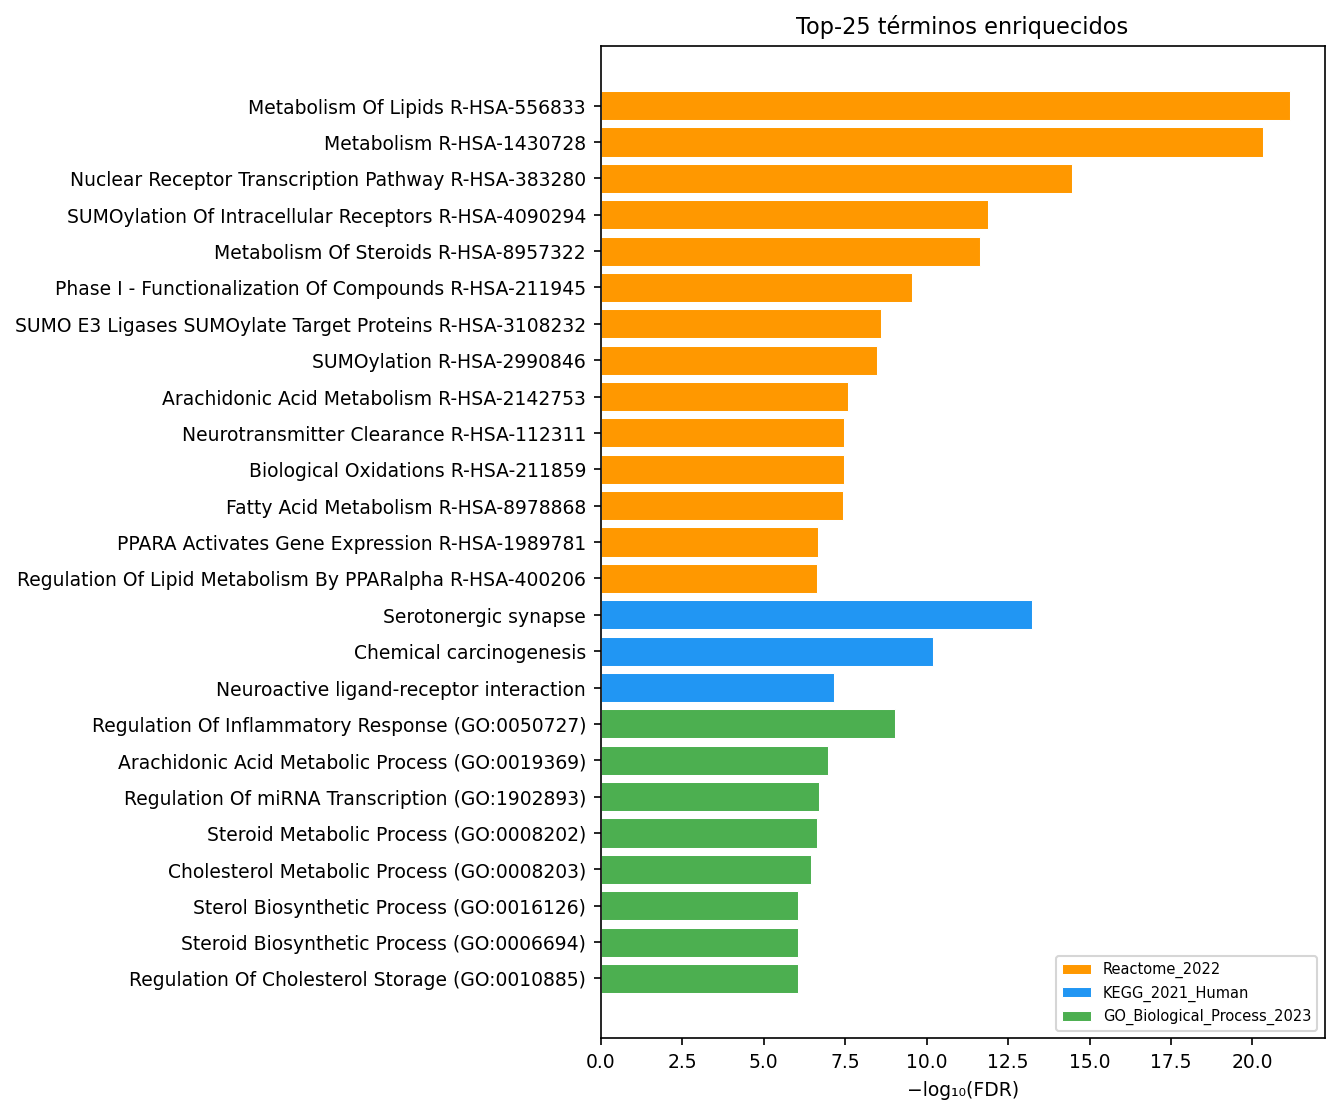

  Guardado: outputs/ppi_network.png


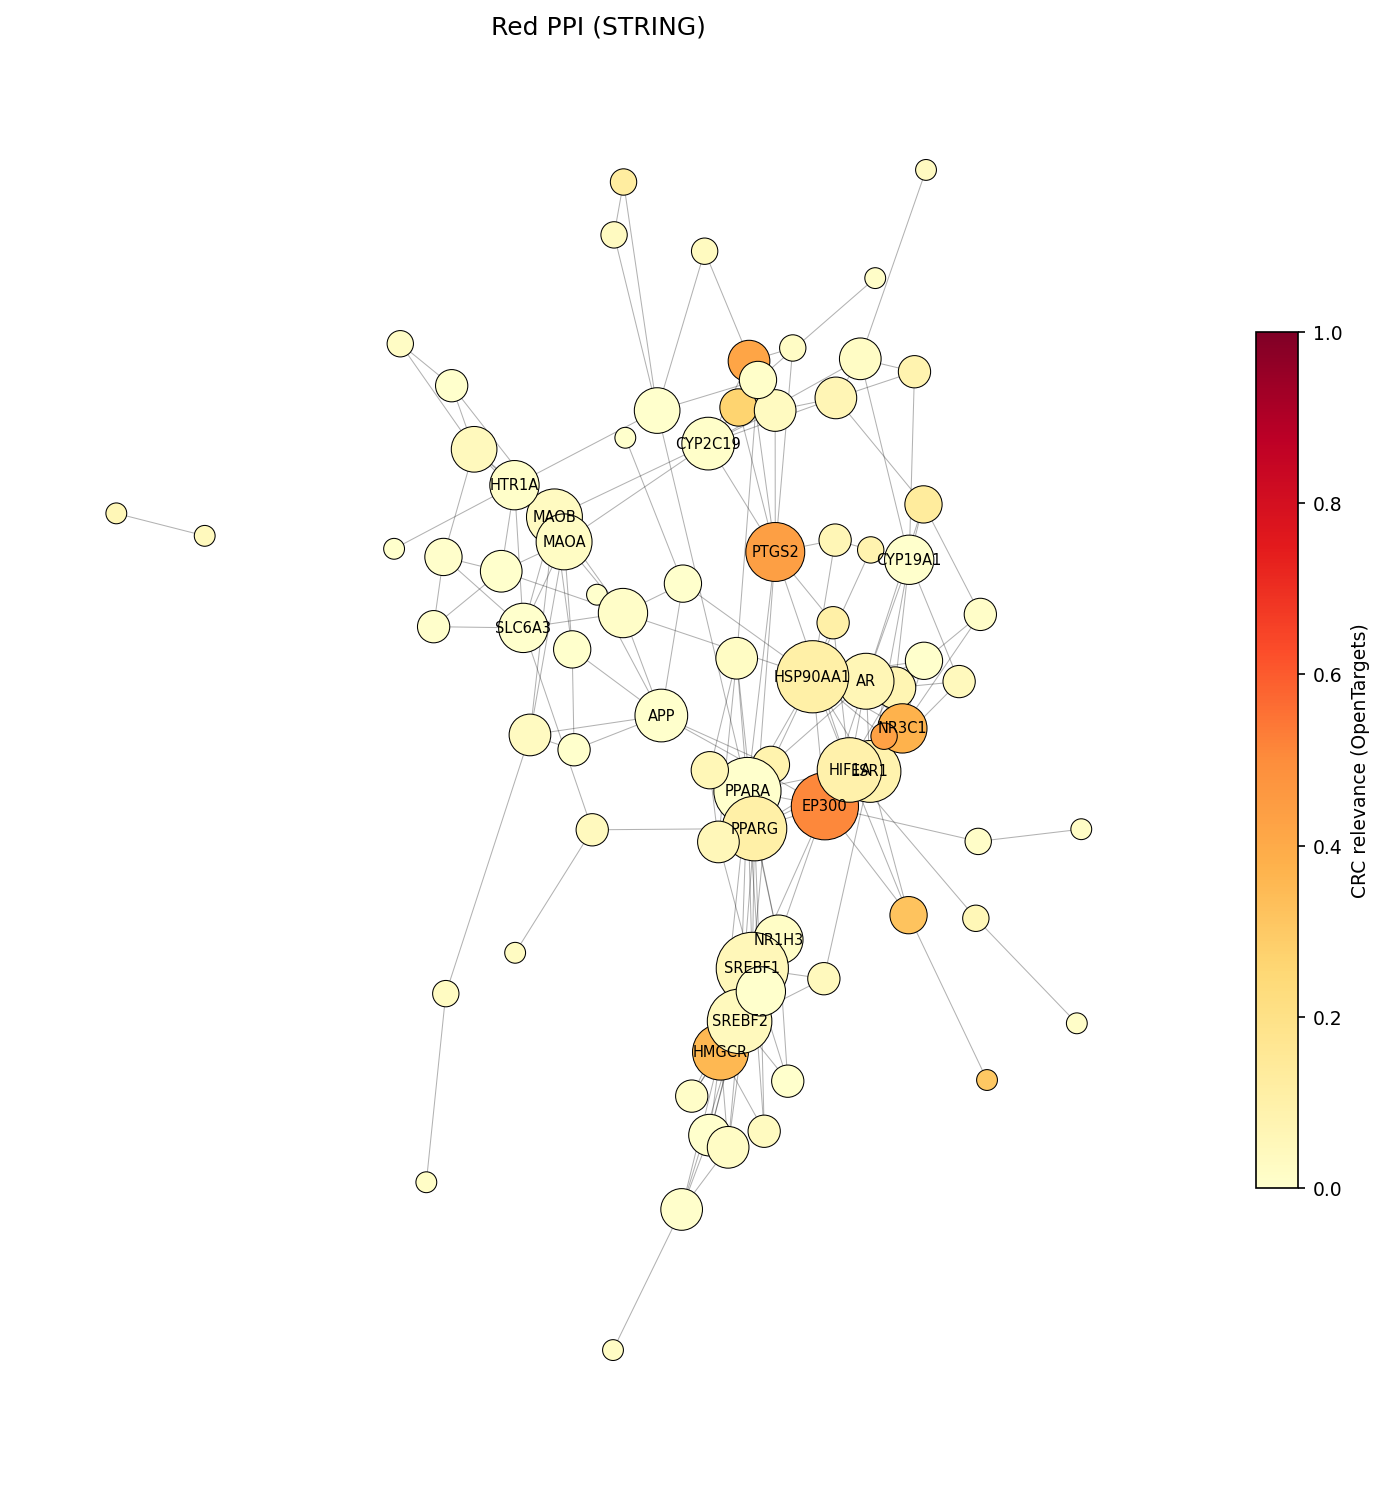

  Guardado: outputs/compound_target_heatmap.png


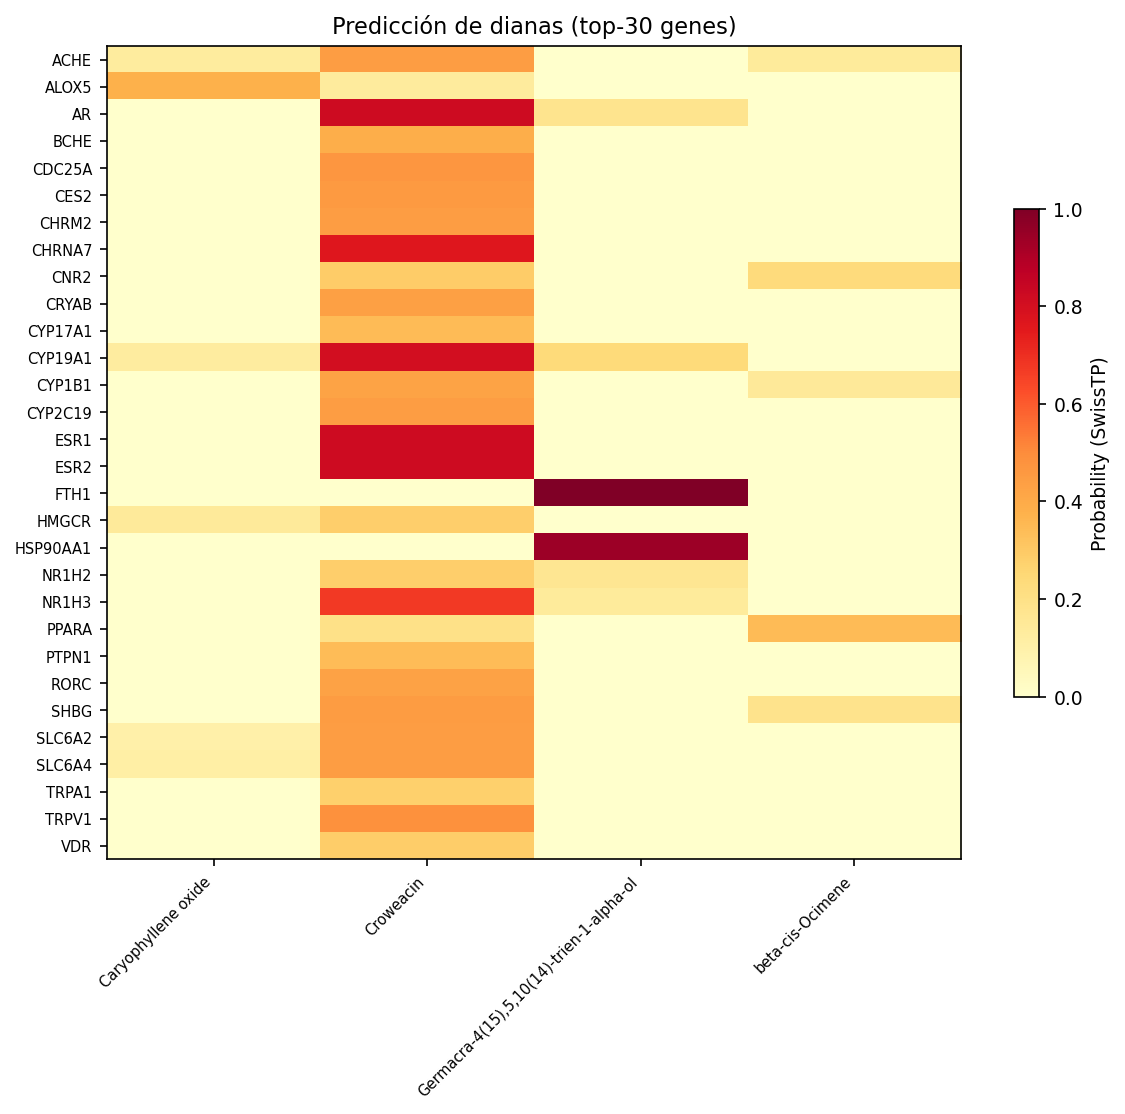

In [48]:
# CELDA 11: PASO 9 — Visualizaciones
# ============================================================

print("\n" + "="*60)
print("PASO 9: Visualizaciones")
print("="*60)

# 9a: Enrichment barplot
if not df_enrichment.empty:
    plot_enrichment_barplot(df_enrichment, top_n=25,
                            output_dir=cfg.output_dir)

# 9b: PPI network
if G_ppi is not None and G_ppi.number_of_edges() > 0:
    plot_ppi_network(G_ppi, df_crc=df_crc, output_dir=cfg.output_dir)

# 9c: Compound-target heatmap
if not df_targets_std.empty:
    plot_compound_target_heatmap(df_targets_std, top_n=30,
                                 output_dir=cfg.output_dir)



In [49]:
# CELDA 12: RESUMEN DEL PIPELINE
# ============================================================

print("\n" + "="*60)
print("RESUMEN DEL PIPELINE")
print("="*60)

print(f"""
Archivos generados en '{cfg.output_dir}/':
  01_identity.csv                  — Identidad química (PubChem)
  02_master_identity.csv           — Identidad + ChEMBL
  02b_chembl_details.csv           — Detalle de actividades ChEMBL
  03_swisstarget_filtered.csv      — Predicciones SwissTP filtradas
  04_targets_standardized.csv      — Genes estandarizados
  04_gene_convergence.csv          — Convergencia de genes
  05_crc_relevance.csv             — Relevancia CRC (OpenTargets)
  pathway_enrichment.csv           — Vías enriquecidas
  ppi_interactions.csv             — Interacciones PPI (STRING)
  07_ppi_metrics.csv               — Métricas de centralidad PPI
  08_prioritized.csv               — Tabla maestra priorizada
  08_phenotype_bridge.csv          — Bridge con fenotipos (completar)
  enrichment_barplot.png           — Figura: enrichment
  ppi_network.png                  — Figura: red PPI
  compound_target_heatmap.png      — Figura: heatmap compuestos×genes

Parámetros usados:
  SwissTP prob threshold:  ≥{cfg.swisstarget_prob_low}
  SwissTP prob high:       ≥{cfg.swisstarget_prob_high}
  Min known actives:       {cfg.min_known_actives}
  Enrichment FDR:          <{cfg.enrichment_fdr_threshold}
  STRING combined score:   ≥{cfg.string_score_threshold}
  CRC disease IDs:         {cfg.crc_disease_ids}
""")




RESUMEN DEL PIPELINE

Archivos generados en 'outputs/':
  01_identity.csv                  — Identidad química (PubChem)
  02_master_identity.csv           — Identidad + ChEMBL
  02b_chembl_details.csv           — Detalle de actividades ChEMBL
  03_swisstarget_filtered.csv      — Predicciones SwissTP filtradas
  04_targets_standardized.csv      — Genes estandarizados
  04_gene_convergence.csv          — Convergencia de genes
  05_crc_relevance.csv             — Relevancia CRC (OpenTargets)
  pathway_enrichment.csv           — Vías enriquecidas
  ppi_interactions.csv             — Interacciones PPI (STRING)
  07_ppi_metrics.csv               — Métricas de centralidad PPI
  08_prioritized.csv               — Tabla maestra priorizada
  08_phenotype_bridge.csv          — Bridge con fenotipos (completar)
  enrichment_barplot.png           — Figura: enrichment
  ppi_network.png                  — Figura: red PPI
  compound_target_heatmap.png      — Figura: heatmap compuestos×genes

Parámetr

In [50]:
# CELDA 13: PRÓXIMOS PASOS
# ============================================================

print("""
═══════════════════════════════════════════════════════════════
PRÓXIMOS PASOS
═══════════════════════════════════════════════════════════════

1. COMPLETAR datos experimentales en 08_phenotype_bridge.csv:
   - mtt_ic50_ugml:    IC50 del aceite/extracto en HCT-116
   - ros_fold_change:  fold-change DCFDA vs control
   - phenotype_note:   observaciones relevantes

2. VERIFICAR identidad de beta-cis-Ocimene:
   - Comparar CID 5281553 con tu índice de retención GC-MS
   - Si no coincide, actualizar verified_cid en la configuración

3. REVISAR vías enriquecidas:
   - ¿Son consistentes con tus observaciones de citotoxicidad/ROS?
   - ¿Aparecen vías de apoptosis, estrés oxidativo, ciclo celular?

4. SELECCIONAR 2-3 targets para docking molecular:
   - Priorizar targets con:
     a) Alto priority_score
     b) Estructura cristalográfica en PDB (resolución ≤ 2.5 Å)
     c) Relevancia CRC STRONG o MODERATE
   - Preparar receptor + ligando para AutoDock Vina

5. REDACTAR la discusión conectando:
   compound → targets → pathways → phenotype experimental
""")



═══════════════════════════════════════════════════════════════
PRÓXIMOS PASOS
═══════════════════════════════════════════════════════════════

1. COMPLETAR datos experimentales en 08_phenotype_bridge.csv:
   - mtt_ic50_ugml:    IC50 del aceite/extracto en HCT-116
   - ros_fold_change:  fold-change DCFDA vs control
   - phenotype_note:   observaciones relevantes

2. VERIFICAR identidad de beta-cis-Ocimene:
   - Comparar CID 5281553 con tu índice de retención GC-MS
   - Si no coincide, actualizar verified_cid en la configuración

3. REVISAR vías enriquecidas:
   - ¿Son consistentes con tus observaciones de citotoxicidad/ROS?
   - ¿Aparecen vías de apoptosis, estrés oxidativo, ciclo celular?

4. SELECCIONAR 2-3 targets para docking molecular:
   - Priorizar targets con:
     a) Alto priority_score
     b) Estructura cristalográfica en PDB (resolución ≤ 2.5 Å)
     c) Relevancia CRC STRONG o MODERATE
   - Preparar receptor + ligando para AutoDock Vina

5. REDACTAR la discusión conectando